In [1]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Tender schedule with starting point

In [36]:
with open('Deterministic_results_with_initial_conditions.json') as json_file:
    F_results = json.load(json_file)


In [37]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["M"]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [38]:
#filter for F and X, to show vaccines allocated per tender

# Extract the 'M' group
m_group = grouped_results.get('M', [])

# Filter dictionaries starting with 'X' or 'F' and exclude those with 'X_tilde'
filtered_dicts = [
    entry for entry in m_group
    if any((key.startswith(('X[', 'F')) and 'X_tilde' not in key) for key in entry)
       and not all(value == 0 for key, value in entry.items())
       and all('HPV' not in key for key in entry)
]

In [39]:
#group the data into X and F

# Function to group items by key start value
def group_by_start_value(items):
    grouped_data = {}

    for item in items:
        key = list(item.keys())[0]  # Extract the key from the dictionary
        start_value = key[0]  # Get the first character of the key
        if start_value not in grouped_data:
            grouped_data[start_value] = []
        grouped_data[start_value].append(item)

    return grouped_data

# Group the data
result = group_by_start_value(filtered_dicts)

result


{'X': [{'X[MMR,Serum_Institute,1]': 13547121.0},
  {'X[M,PT_Bio,7]': 1.3038516044616705e-07},
  {'X[MMR,GSK,2]': 181287900.0},
  {'X[MR,Serum_Institute,3]': 238044671.46200436},
  {'X[MR,Biological_E,2]': 28142136.46200438},
  {'X[MR,Serum_Institute,2]': 186669963.53799564},
  {'X[MR,Serum_Institute,7]': 200960255.4926465},
  {'X[M,PT_Bio,2]': 2570320.538759881},
  {'X[M,Serum_Institute,1]': 16280000.0},
  {'X[MR,Serum_Institute,10]': 258493631.96820837},
  {'X[M,PT_Bio,9]': 2.1979212760925304e-07},
  {'X[M,PT_Bio,10]': 2.7939677238464366e-07},
  {'X[MMR,Merck_Sharp,1]': 2574979.0},
  {'X[MR,Biological_E,9]': 51127036.51226855},
  {'X[M,PT_Bio,5]': 17471469.773748264},
  {'X[MR,Serum_Institute,8]': 376799999.99999994},
  {'X[MR,Biological_E,5]': 147500000.0},
  {'X[MR,Serum_Institute,6]': 370300000.0},
  {'X[M,PT_Bio,4]': 26228530.226251744},
  {'X[MR,Biological_E,10]': 54406368.03179161},
  {'X[MR,Biological_E,3]': 40755328.53799562},
  {'X[M,PT_Bio,8]': 1.6018748283386236e-07},
  {'X

In [40]:
# create dictionary from F data from above
# Extracting information from the dictionary
data_list = []
for item in result['F']:
    key, value = list(item.items())[0]
    # print(key)
    tender = key.split('[', 1)[1].split(',', 1)[0]
    start, finish = eval(key.split('(', 1)[1].split(')', 1)[0])
    value = item[key]
    
    data_list.append({'Tender': tender, 'Start': start, 'Finish': finish, 'Value': value})

# Create a DataFrame
F_values_df = pd.DataFrame(data_list)
F_values_df = F_values_df[F_values_df.Tender == 'Measles']
F_values_df.Start = F_values_df.Start -1
# Display the DataFrame
F_values_df


,Tender,Start,Finish,Value
1,Measles,0,5,1.0
4,Measles,5,10,1.0
5,Measles,-2,3,1.0


In [41]:

# Extracting data for the DataFrame
df_data = []
for entry in result['X']:
    key, value = entry.popitem()
    vaccine = key.split(',')[0][2:]
    producer = key.split(',')[1].strip()
    start = int(key.split(',')[2].split(']')[0])
    end = int(start)
    df_data.append({'Vaccine': vaccine, 'Producer': producer, 'Start': start, 'End': end, 'Value': value})

# Creating DataFrame
X_data = pd.DataFrame(df_data)

# Print the DataFrame
X_data


,Vaccine,Producer,Start,End,Value
0,MMR,Serum_Institute,1,1,1.354712e+07
1,M,PT_Bio,7,7,1.303852e-07
2,MMR,GSK,2,2,1.812879e+08
3,MR,Serum_Institute,3,3,2.380447e+08
4,MR,Biological_E,2,2,2.814214e+07
5,MR,Serum_Institute,2,2,1.866700e+08
6,MR,Serum_Institute,7,7,2.009603e+08
7,M,PT_Bio,2,2,2.570321e+06
8,M,Serum_Institute,1,1,1.628000e+07
9,MR,Serum_Institute,10,10,2.584936e+08


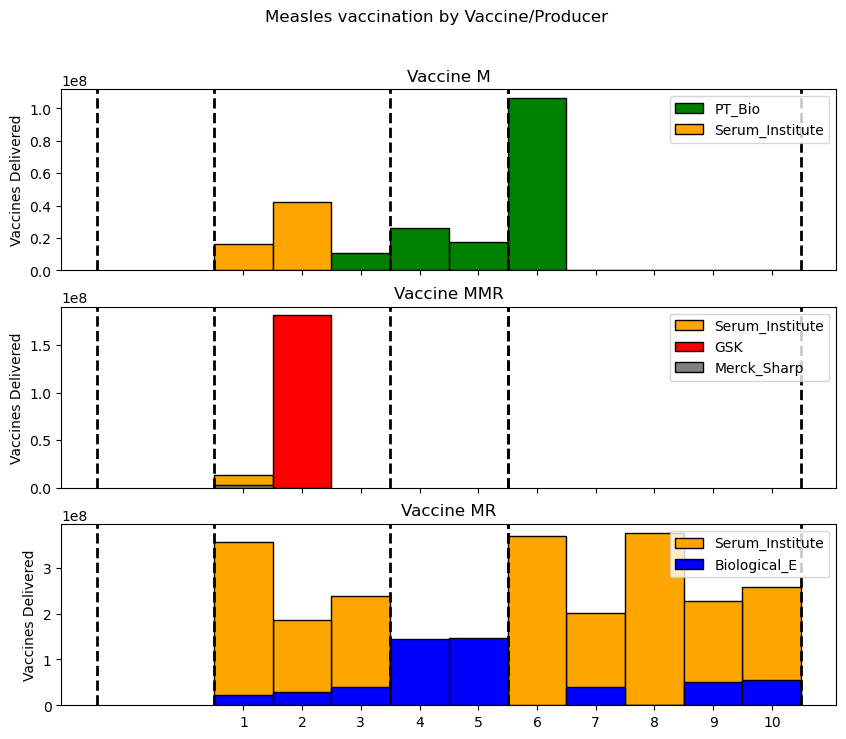

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Using DataFrame.insert() to add a column
F_values_df.insert(2, "Color", ['green', 'blue', 'orange'], True)

# Create subplots for each vaccine
fig, axs = plt.subplots(nrows=len(X_data['Vaccine'].unique()), figsize=(10, 8), sharex=True)

# Define unique colors for each producer
producer_colors = {'Biological_E': 'blue', 'Serum_Institute': 'orange', 'PT_Bio': 'green', 'GSK': 'red', 'Merck_Sharp':'grey'}

# Plot stacked bars for each vaccine
for i, (vaccine, group) in enumerate(X_data.groupby('Vaccine')):
    producers = group['Producer'].unique()
    
    for producer in producers:
        producer_data = group[group['Producer'] == producer]
        axs[i].bar(producer_data['Start'], producer_data['Value'], label=producer, bottom=np.zeros(len(producer_data)), width=1.0, edgecolor='black', linewidth=1, color=producer_colors.get(producer, 'gray'))

    axs[i].set_title(f'Vaccine {vaccine}')
    axs[i].set_ylabel('Vaccines Delivered')
    axs[i].legend()
    
        # Plot lines from the second DataFrame using axvline
    for _, row in F_values_df.iterrows():    
         # Add vertical lines at start and finish points
        axs[i].axvline(x=row['Start']+0.5, color='black',
                      linestyle='--', linewidth=2)
        axs[i].axvline(x=row['Finish']+0.5, color='black',
                      linestyle='--', linewidth=2)


# Set x-axis ticks for each year
for ax in axs.flat:
    ax.set_xticks(np.arange(min(X_data['Start']), max(X_data['End']) + 1, 1))
    # ax.set_xlabel('Time (Start)')


plt.suptitle('Measles vaccination by Vaccine/Producer')
plt.savefig('det_tenders_and_vaccines.png', bbox_inches='tight', pad_inches=0.1)
plt.show()
